# Indexing visualisation

Visualise how an index selects elements with `index`.

In [1]:
import numpy as np

import rainbow_tensor as rt

For the array `np.arange(8).reshape(2, 2, 2)` the index `(0, slice(None), 1)` selects the values 1 and 3.

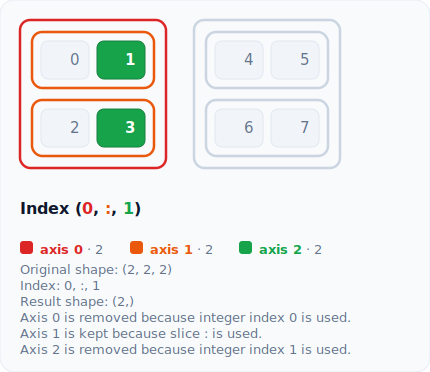

In [2]:
rt.index(np.arange(8).reshape(2, 2, 2), (0, slice(None), 1))

Slices keep an axis. Here axis 1 is kept and the result shape is `(2, 2)`.

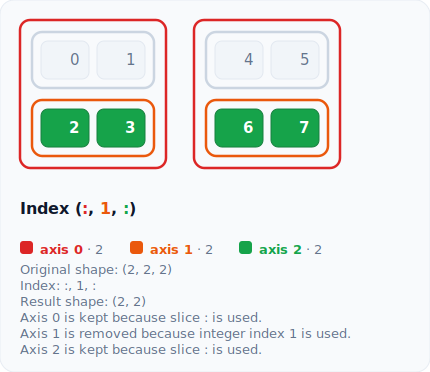

In [3]:
rt.index(np.arange(8).reshape(2, 2, 2), (slice(None), 1, slice(None)))

## Dark theme

An index view reads just as clearly in the dark theme. The selected path keeps its colour while the rest of the tensor is dimmed.

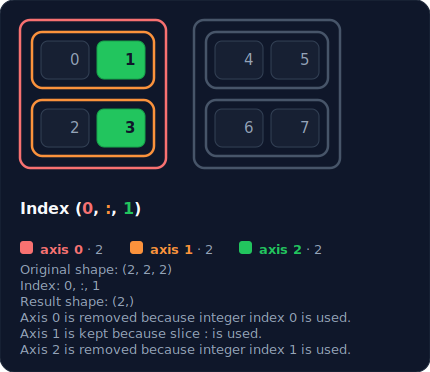

In [4]:
rt.index(np.arange(8).reshape(2, 2, 2), (0, slice(None), 1), theme="dark")

## Float values and precision

Real float arrays format to a chosen precision, and the selected values stay aligned with the rest of the column.

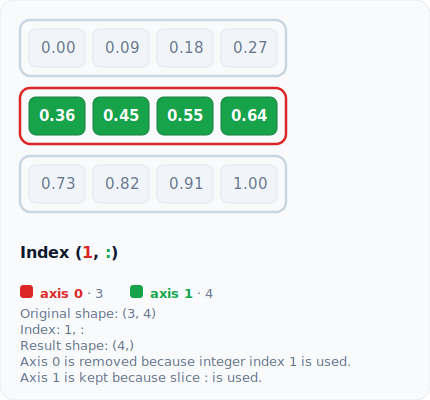

In [5]:
f = np.linspace(0, 1, 12).reshape(3, 4)
rt.index(f, (1, slice(None)), precision=2)

## Negative indices

Negative integers count from the end. Here `-1` is the last block, the same as `1`.

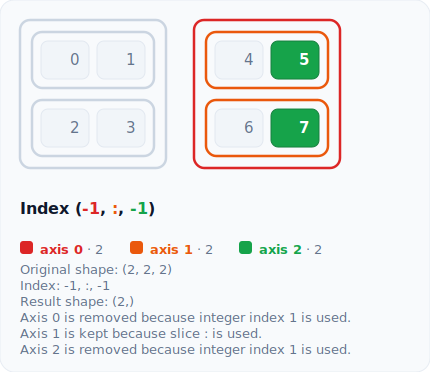

In [6]:
rt.index(np.arange(8).reshape(2, 2, 2), (-1, slice(None), -1))

## Reversed and stepped slices

Slice bounds and steps may be negative. `::-1` reverses an axis and `4:1:-1` walks it backwards.

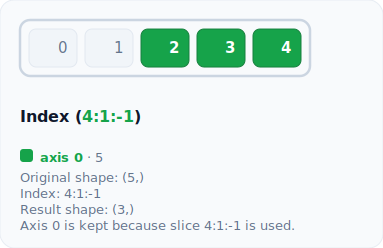

In [7]:
rt.index(np.arange(5), (slice(4, 1, -1),))

## Ellipsis

`...` fills the axes you leave out, so `(0, ..., 1)` keeps the middle axis without naming it.

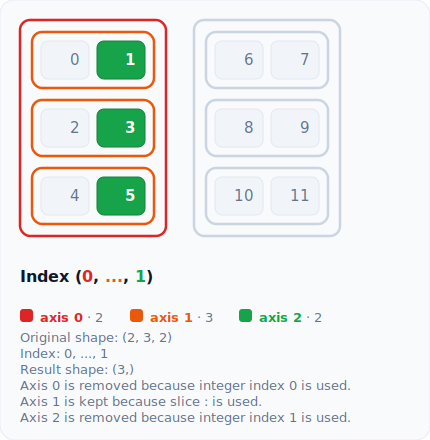

In [8]:
rt.index(np.arange(12).reshape(2, 3, 2), (0, ..., 1))

## New axis with None

`None` inserts a size 1 axis. The selection is unchanged but the result shape gains a `1`, named in the explanation.

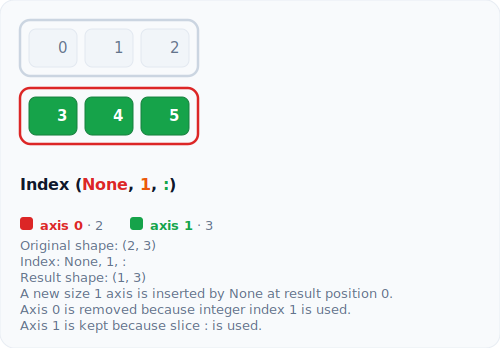

In [9]:
rt.index(np.arange(6).reshape(2, 3), (None, 1, slice(None)))

## Clear error messages

An out of range index points at the offending axis instead of failing silently.

In [10]:
try:
    rt.index(np.arange(8).reshape(2, 2, 2), (2, slice(None), 1))
except IndexError as e:
    print(e)

axis 0: index 2 is out of range for size 2


## Higher dimensions

Indexing works at any rank. Here a 4D tensor keeps axes 1 and 3 and the result shape is `(2, 2)`.

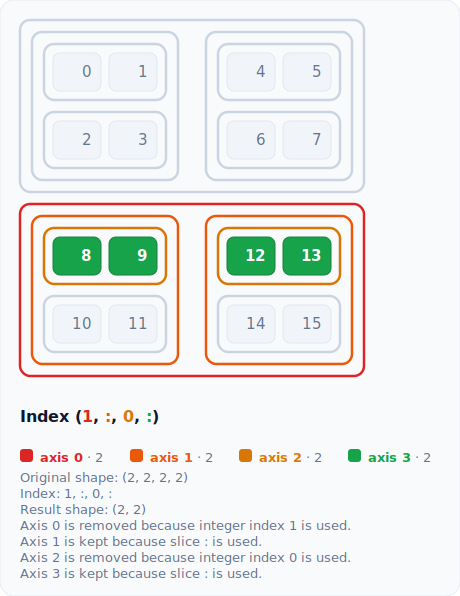

In [11]:
rt.index(np.arange(16).reshape(2, 2, 2, 2), (1, slice(None), 0, slice(None)))